# Parte 1 — Datos y Tokenización
### Análisis de Sentimiento IMDB · DistilBERT

Este notebook prepara todo lo que los siguientes notebooks necesitan:
- Explorar el dataset (EDA)
- Entender la tokenización WordPiece
- Guardar el dataset tokenizado a disco para reutilizarlo sin reprocesar

In [ ]:
# !pip install 'transformers[torch]' 'accelerate>=1.1.0' datasets evaluate scikit-learn matplotlib seaborn -q

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer

SEED            = 42
MODEL_CHECKPOINT = "distilbert-base-uncased"
SUBSET_SIZE     = 10_000   # None = dataset completo
MAX_LENGTH      = 256
DATASET_PATH    = "./tokenized_dataset"   # donde se guarda para los siguientes notebooks

np.random.seed(SEED)
torch.manual_seed(SEED)
print("Config OK")

Config OK


## 1. Carga del dataset

In [2]:
raw_dataset = load_dataset("imdb")

if SUBSET_SIZE is not None:
    raw_dataset["train"] = raw_dataset["train"].shuffle(seed=SEED).select(range(SUBSET_SIZE))
    raw_dataset["test"]  = raw_dataset["test"].shuffle(seed=SEED).select(range(SUBSET_SIZE // 5))

split = raw_dataset["train"].train_test_split(test_size=0.2, seed=SEED)
dataset = DatasetDict({
    "train":      split["train"],
    "validation": split["test"],
    "test":       raw_dataset["test"],
})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## 2. EDA

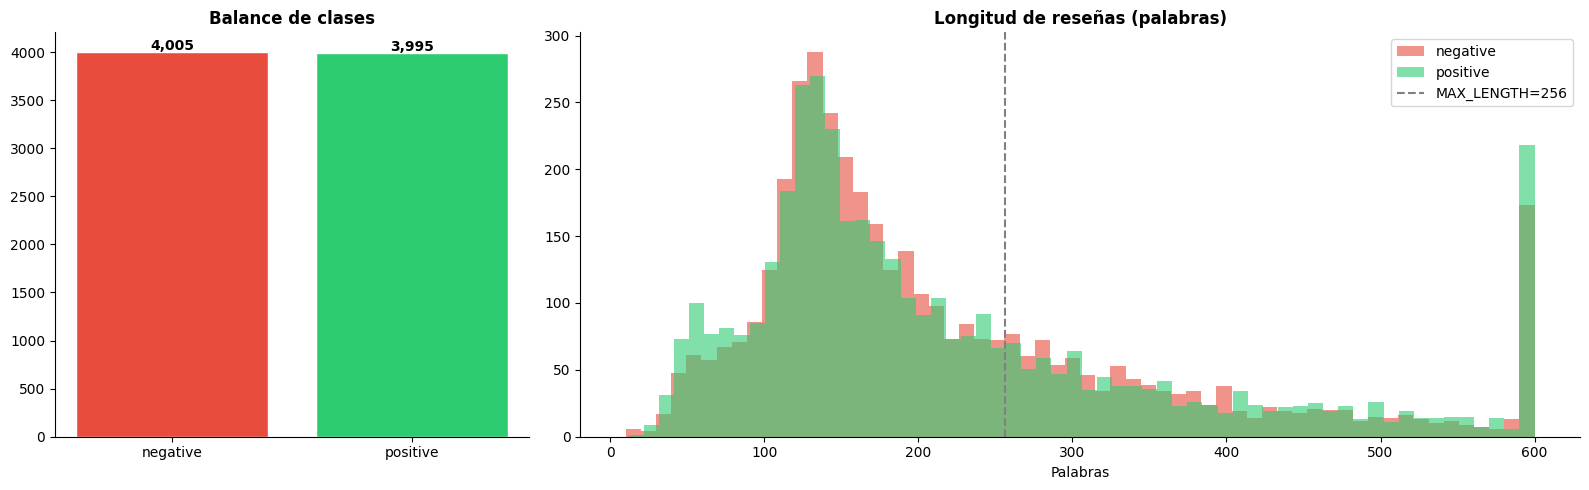

Reseñas que serán truncadas: 29.0%


In [3]:
def clean_html(text):
    return re.sub(r"<[^>]+>", " ", text)

df = dataset["train"].to_pandas()
df["text_clean"] = df["text"].apply(clean_html)
df["n_words"]    = df["text_clean"].str.split().str.len()
df["sentiment"]  = df["label"].map({0: "negative", 1: "positive"})

PALETTE = {"positive": "#2ecc71", "negative": "#e74c3c"}

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
counts = df["sentiment"].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=[PALETTE[k] for k in counts.index], edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val:,}", ha="center", fontweight="bold")
ax1.set_title("Balance de clases", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1:])
for sentiment, group in df.groupby("sentiment"):
    ax2.hist(group["n_words"].clip(upper=600), bins=60, alpha=0.6,
             label=sentiment, color=PALETTE[sentiment])
ax2.axvline(MAX_LENGTH, color="gray", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
ax2.set_title("Longitud de reseñas (palabras)", fontweight="bold")
ax2.set_xlabel("Palabras"); ax2.legend()
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

trunc = (df["n_words"] > MAX_LENGTH).mean() * 100
print(f"Reseñas que serán truncadas: {trunc:.1f}%")

## 3. Tokenización

DistilBERT usa **WordPiece**: las palabras desconocidas se descomponen en subpalabras.

`"unbelievable"` → `['un', '##believe', '##able']`

Cada secuencia se envuelve con `[CLS]` al inicio y `[SEP]` al final.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Inspección rápida
sample = "The movie was absolutely unbelievable — a masterpiece!"
tokens = tokenizer.convert_ids_to_tokens(tokenizer(sample)["input_ids"])
print("Texto  :", sample)
print("Tokens :", tokens)
print(f"Total  : {len(tokens)} tokens")

Texto  : The movie was absolutely unbelievable — a masterpiece!
Tokens : ['[CLS]', 'the', 'movie', 'was', 'absolutely', 'unbelievable', '—', 'a', 'masterpiece', '!', '[SEP]']
Total  : 11 tokens


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


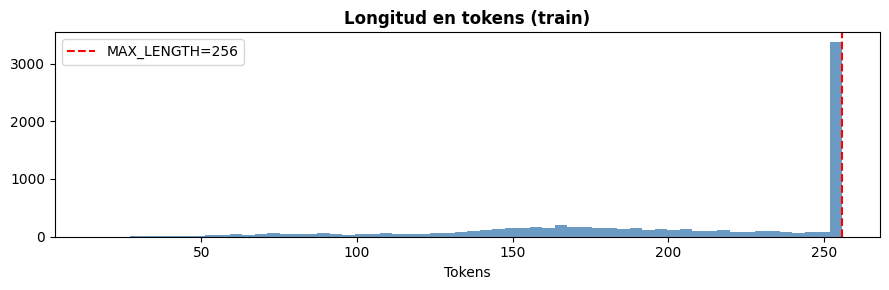

Media: 203  |  Truncadas: 41.3%


In [5]:
def preprocess(examples):
    texts = [re.sub(r"<[^>]+>", " ", t) for t in examples["text"]]
    return tokenizer(texts, truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(
    preprocess,
    batched=True,
    remove_columns=["text"],
)
print(tokenized_dataset)

# Distribución de longitudes post-tokenización
lens = [len(x) for x in tokenized_dataset["train"]["input_ids"]]
plt.figure(figsize=(9, 3))
plt.hist(lens, bins=60, color="steelblue", alpha=0.8)
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"MAX_LENGTH={MAX_LENGTH}")
plt.title("Longitud en tokens (train)", fontweight="bold")
plt.xlabel("Tokens"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Media: {np.mean(lens):.0f}  |  Truncadas: {sum(l==MAX_LENGTH for l in lens)/len(lens)*100:.1f}%")

## 4. Guardar dataset tokenizado

Los siguientes notebooks cargan desde aquí — sin necesidad de retokenizar.

In [6]:
tokenized_dataset.save_to_disk(DATASET_PATH)
print(f"Dataset guardado en '{DATASET_PATH}'")
print("Columnas:", tokenized_dataset["train"].column_names)

Saving the dataset (0/1 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset guardado en './tokenized_dataset'
Columnas: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
